Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Clone Repository

In [5]:
!git clone https://github.com/shefiramarizcha62-sudo/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-.git

Cloning into 'Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 150 (delta 50), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 3.45 MiB | 7.65 MiB/s, done.
Resolving deltas: 100% (50/50), done.


Masuk ke Folder Project

In [6]:
%cd Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-

/content/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-


Cek Isi Folder

In [7]:
ls

data/  docs/  notebooks/  README.md  requirements.txt  results/  src/


Import Library

In [8]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

Load Dataset

In [9]:
columns = ['unit_number','time_in_cycles',
           'op_setting_1','op_setting_2','op_setting_3']

sensor_columns = [f'sensor_{i}' for i in range(1,22)]

columns.extend(sensor_columns)

train_df = pd.read_csv(
    'data/train_FD001.txt',
    sep='\s+',
    header=None
)

train_df = train_df.iloc[:,:26]

train_df.columns = columns

train_df.head()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_767/2593744736.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Hitung RUL

In [10]:
rul = train_df.groupby('unit_number')['time_in_cycles'].max()

train_df = train_df.merge(
    rul.to_frame(name='max_cycle'),
    on='unit_number'
)

train_df['RUL'] = (
    train_df['max_cycle']
    - train_df['time_in_cycles']
)

Piece-wise RUL

In [11]:
max_rul = 125

train_df['RUL'] = train_df['RUL'].clip(upper=max_rul)

Feature Selection

In [12]:
sensor_cols = sensor_columns

train_df[sensor_cols].std().sort_values()

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,1.556432e-14
sensor_10,4.660829e-13
sensor_5,3.394700e-12
sensor_1,6.537152e-11
sensor_6,1.388985e-03
sensor_15,3.750504e-02
sensor_8,7.098548e-02
sensor_13,7.191892e-02


In [13]:
drop_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

train_df = train_df.drop(columns=drop_sensors)

Normalization

In [14]:
features = train_df.columns.difference([
    'unit_number',
    'time_in_cycles',
    'RUL',
    'max_cycle'
])

scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(
    train_df[features]
)

Denoising

In [15]:
train_df['sensor_2_smooth'] = (
    train_df.groupby('unit_number')['sensor_2']
    .transform(lambda x: x.rolling(5).mean())
)

In [16]:
train_df = train_df.fillna(method='bfill')

/tmp/ipykernel_767/1550443520.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.fillna(method='bfill')


VISUALISASI BEFORE/AFTER SMOOTHING

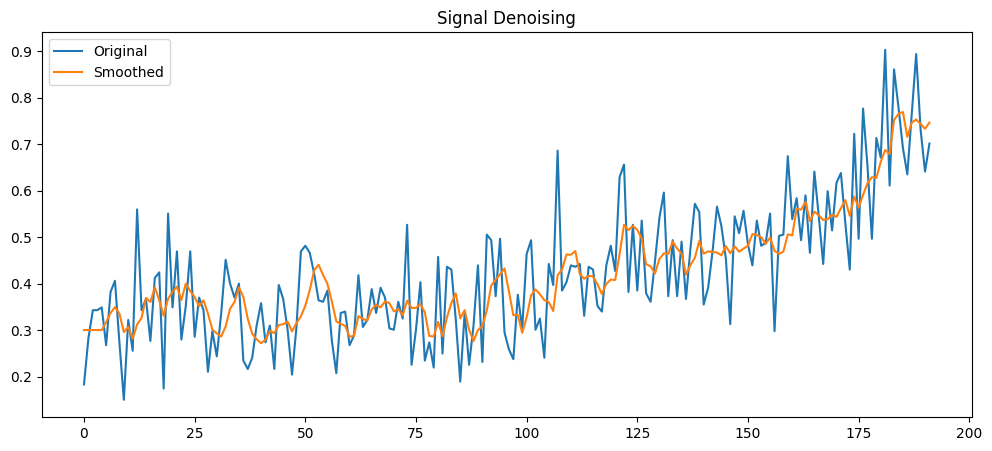

In [17]:
engine_1 = train_df[train_df['unit_number']==1]

plt.figure(figsize=(12,5))

plt.plot(engine_1['sensor_2'], label='Original')
plt.plot(engine_1['sensor_2_smooth'], label='Smoothed')

plt.legend()
plt.title('Signal Denoising')
plt.show()

Sequence Generation

Sequence Length

In [18]:
sequence_length = 30

Function

In [19]:
def create_sequences(data, seq_length, feature_cols):

    X = []
    y = []

    for unit in data['unit_number'].unique():

        unit_df = data[data['unit_number']==unit].copy()

        for i in range(len(unit_df)-seq_length):

            seq_x = unit_df[feature_cols].iloc[
                i:i+seq_length
            ].values

            seq_y = unit_df['RUL'].iloc[
                i+seq_length
            ]

            X.append(seq_x)
            y.append(seq_y)

    return np.array(X), np.array(y)

Generate Sequence

In [20]:
feature_cols = features.tolist()

X_train, y_train = create_sequences(
    train_df,
    sequence_length,
    feature_cols
)

print(X_train.shape)
print(y_train.shape)

(17631, 30, 18)
(17631,)


Save Hasil

In [21]:
np.save('data/X_train.npy', X_train)
np.save('data/y_train.npy', y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17631, 30, 18)
y_train shape: (17631,)


# BASELINE 1D-CNN

TRAIN VALIDATION SPLIT

In [22]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

TRANSFORMER IMPORTS

In [23]:
import tensorflow as tf

from tensorflow.keras import Input
from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)

TRANSFORMER ENCODER

In [24]:
def transformer_encoder(
    inputs,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.0
):

    attention = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(inputs, inputs)

    attention = Dropout(dropout)(attention)

    attention = LayerNormalization(
        epsilon=1e-6
    )(attention)

    res = attention + inputs

    ff = Dense(
        ff_dim,
        activation="relu"
    )(res)

    ff = Dense(
        inputs.shape[-1]
    )(ff)

    ff = LayerNormalization(
        epsilon=1e-6
    )(ff)

    return ff + res

BUILD TRANSFORMER MODEL

In [25]:
inputs = Input(
    shape=(
        X_train_split.shape[1],
        X_train_split.shape[2]
    )
)

x = transformer_encoder(
    inputs,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = GlobalAveragePooling1D()(x)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(1)(x)

model = Model(
    inputs,
    outputs
)

COMPILE MODEL

In [26]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 18)    │     19,218 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 18)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 18)    │         36 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 18)    │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │      2,432 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 18)    │      2,322 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 18)    │         36 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 18)    │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 18)        │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      1,216 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,325 (98.93 KB)

 Trainable params: 25,325 (98.93 KB)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [27]:
history = model.fit(
    X_train_split,
    y_train_split,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - loss: 4077.6111 - mae: 52.6086 - val_loss: 617.7189 - val_mae: 21.2106
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 614.2081 - mae: 19.3059 - val_loss: 397.3004 - val_mae: 15.2714
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 548.5168 - mae: 18.0300 - val_loss: 398.4130 - val_mae: 14.5796
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 531.1948 - mae: 17.7122 - val_loss: 414.3197 - val_mae: 14.7560
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - loss: 518.7250 - mae: 17.4563 - val_loss: 394.0479 - val_mae: 14.1107
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 498.2743 - mae: 16.9931 - val_loss: 396.9706 - val_mae: 15.3012
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 469.7507 - mae: 16.4355 - val_loss: 353.9707 - val_mae: 14.0461
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - loss: 473.2060 - mae: 16.5258 - val_loss: 371.9937 - val_mae:

EVALUASI

In [28]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_val)

rmse = np.sqrt(
    mean_squared_error(y_val, pred)
)

mae = mean_absolute_error(y_val, pred)

print("RMSE:", rmse)
print("MAE :", mae)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
RMSE: 16.54009207943214
MAE : 12.098363876342773


MODEL COMPARISON

In [31]:
import pandas as pd

comparison = pd.DataFrame({

    'Model': [
        '1D-CNN',
        'CNN-LSTM',
        'Transformer'
    ],

    'RMSE': [
        14.46,
        13.24,
        rmse
    ],

    'MAE': [
        11.00,
        9.68,
        mae
    ]
})

comparison

,Model,RMSE,MAE
0,1D-CNN,14.460000,11.000000
1,CNN-LSTM,13.240000,9.680000
2,Transformer,16.540092,12.098364


PLOT LOSS

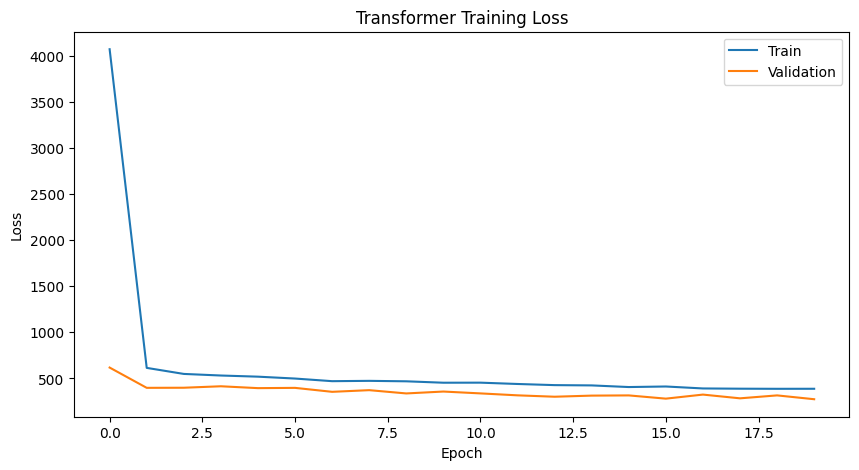

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Transformer Training Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.savefig(
    'results/figures/transformer_loss.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

PLOT PREDICTION

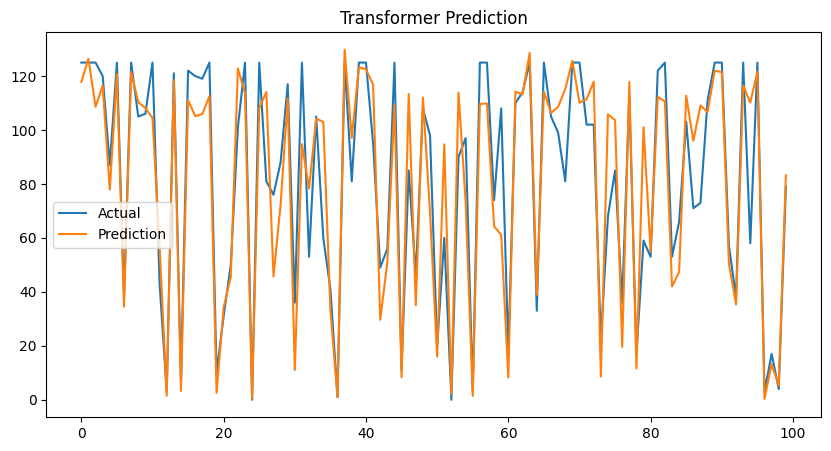

In [33]:
plt.figure(figsize=(10,5))

plt.plot(y_val[:100], label='Actual')
plt.plot(pred[:100], label='Prediction')

plt.legend()

plt.title('Transformer Prediction')

plt.savefig(
    'results/figures/transformer_prediction.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

SAVE TRANSFORMER MODEL

In [34]:
model.save(
    'results/models/transformer_model.keras'
)

SAVE METRICS

In [35]:
with open(
    'results/metrics/transformer_results.txt',
    'w'
) as f:

    f.write(f'RMSE: {rmse}\n')
    f.write(f'MAE : {mae}\n')

MODEL SUMMARY

In [36]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 18)    │     19,218 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 18)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 18)    │         36 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 18)    │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │      2,432 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 18)    │      2,322 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 18)    │         36 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 18)    │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 18)        │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      1,216 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 75,977 (296.79 KB)

 Trainable params: 25,325 (98.93 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,652 (197.86 KB)